In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_erros = pd.read_parquet(
    "../data/analytical/evaluation/erros_linear.parquet"
)

df_erros.head()

,id_municipio,real,previsto,erro,erro_absoluto,Municipio,UF,meta_alfabetizacao_2024
0,2803401,39.30,35.215478,4.084522,4.084522,Japoatã,SE,33.27
1,2702801,49.34,49.427750,-0.087750,0.087750,Flexeiras,AL,41.50
2,2909505,34.55,46.612652,-12.062652,12.062652,Cravolândia,BA,61.09
3,3150570,64.82,67.911903,-3.091903,3.091903,Pintópolis,MG,53.21
4,3526605,46.14,60.082754,-13.942754,13.942754,Lavrinhas,SP,57.18


In [15]:
df_erros[
    ["real", "previsto", "erro", "erro_absoluto"]
].describe()

,real,previsto,erro,erro_absoluto
count,1047.000000,1047.000000,1047.000000,1047.000000
mean,62.631538,62.749494,-0.117956,8.484017
std,18.914803,15.506551,11.192956,7.297180
min,7.100000,7.417225,-40.939707,0.029739
25%,48.845000,52.998557,-6.537483,3.031947
50%,63.350000,64.198168,0.107395,6.406584
75%,77.055000,74.242229,6.292429,12.241657
max,100.000000,96.098490,40.832775,40.939707


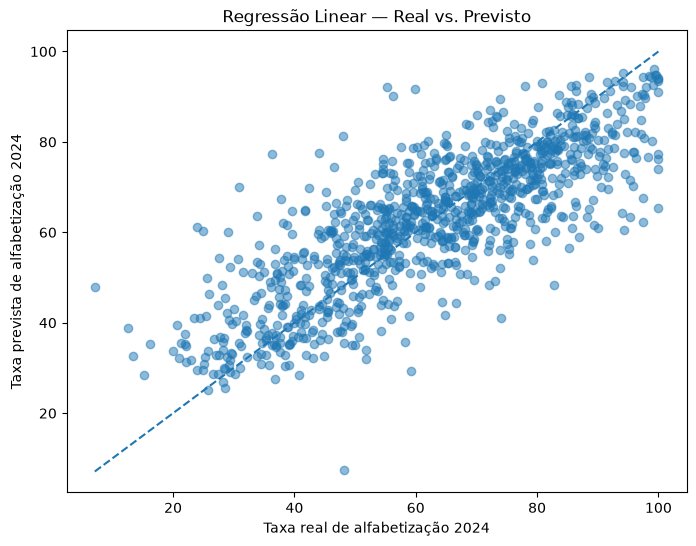

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    df_erros["real"],
    df_erros["previsto"],
    alpha=0.5
)

limite_min = min(
    df_erros["real"].min(),
    df_erros["previsto"].min()
)

limite_max = max(
    df_erros["real"].max(),
    df_erros["previsto"].max()
)

plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle="--"
)

plt.xlabel("Taxa real de alfabetização 2024")
plt.ylabel("Taxa prevista de alfabetização 2024")
plt.title("Regressão Linear — Real vs. Previsto")

plt.show()

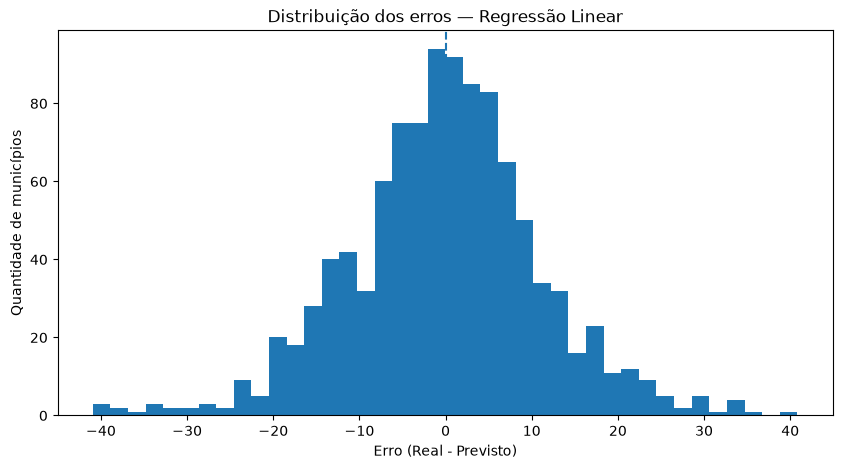

In [4]:
plt.figure(figsize=(10, 5))

plt.hist(
    df_erros["erro"],
    bins=40
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Erro (Real - Previsto)")
plt.ylabel("Quantidade de municípios")
plt.title("Distribuição dos erros — Regressão Linear")

plt.show()

C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_18204\1327114228.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


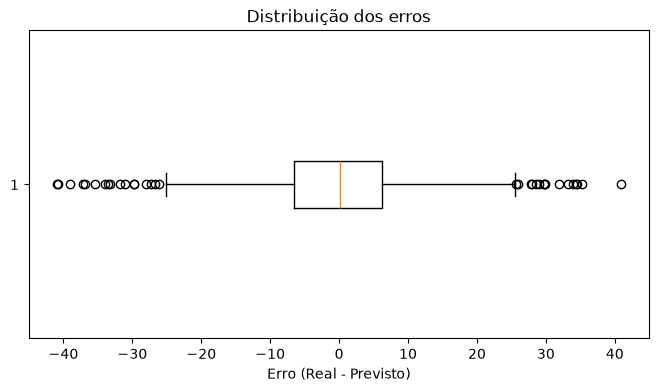

In [5]:
plt.figure(figsize=(8, 4))

plt.boxplot(
    df_erros["erro"],
    vert=False
)

plt.xlabel("Erro (Real - Previsto)")
plt.title("Distribuição dos erros")

plt.show()

In [6]:
piores_erros = (
    df_erros
    .sort_values("erro_absoluto", ascending=False)
    .head(10)
)

piores_erros

,id_municipio,real,previsto,erro,erro_absoluto,Municipio,UF,meta_alfabetizacao_2024
664,4218954,36.34,77.279707,-40.939707,40.939707,Urupema,SC,80.00
315,3550308,48.25,7.417225,40.832775,40.832775,São Paulo,SP,44.37
632,4319208,7.10,47.893440,-40.793440,40.793440,São Nicolau,RS,61.56
757,2210904,30.86,69.958125,-39.098125,39.098125,Socorro do Piauí,PI,70.30
959,1711100,24.00,61.204354,-37.204354,37.204354,Itaporã do Tocantins,TO,66.76
411,3100708,55.30,92.170256,-36.870256,36.870256,Água Comprida,MG,80.00
982,4310850,25.00,60.396922,-35.396922,35.396922,Jaboticaba,RS,80.00
1023,2513984,97.50,62.234788,35.265212,35.265212,São Francisco,PB,60.48
858,4315008,100.00,65.467598,34.532402,34.532402,Porto Lucena,RS,78.78
428,2508406,82.76,48.360361,34.399639,34.399639,Lastro,PB,27.90


In [7]:
subestimativas = (
    df_erros
    .sort_values("erro", ascending=False)
    .head(10)
)

subestimativas

,id_municipio,real,previsto,erro,erro_absoluto,Municipio,UF,meta_alfabetizacao_2024
315,3550308,48.25,7.417225,40.832775,40.832775,São Paulo,SP,44.37
1023,2513984,97.50,62.234788,35.265212,35.265212,São Francisco,PB,60.48
858,4315008,100.00,65.467598,34.532402,34.532402,Porto Lucena,RS,78.78
428,2508406,82.76,48.360361,34.399639,34.399639,Lastro,PB,27.90
743,4313003,94.40,60.416020,33.983980,33.983980,Nova Bréscia,RS,77.71
418,1502509,74.09,40.945943,33.144057,33.144057,Chaves,PA,50.48
73,2201988,95.35,63.393700,31.956300,31.956300,Brejo do Piauí,PI,55.21
920,2505006,97.47,67.615153,29.854847,29.854847,Cubati,PB,73.11
871,2209906,93.97,64.176587,29.793413,29.793413,São João da Serra,PI,54.30
376,2900306,59.14,29.410223,29.729777,29.729777,Acajutiba,BA,26.77


In [8]:
superestimativas = (
    df_erros
    .sort_values("erro", ascending=True)
    .head(10)
)

superestimativas

,id_municipio,real,previsto,erro,erro_absoluto,Municipio,UF,meta_alfabetizacao_2024
664,4218954,36.34,77.279707,-40.939707,40.939707,Urupema,SC,80.00
632,4319208,7.10,47.893440,-40.793440,40.793440,São Nicolau,RS,61.56
757,2210904,30.86,69.958125,-39.098125,39.098125,Socorro do Piauí,PI,70.30
959,1711100,24.00,61.204354,-37.204354,37.204354,Itaporã do Tocantins,TO,66.76
411,3100708,55.30,92.170256,-36.870256,36.870256,Água Comprida,MG,80.00
982,4310850,25.00,60.396922,-35.396922,35.396922,Jaboticaba,RS,80.00
186,3137106,56.25,90.157930,-33.907930,33.907930,Lagamar,MG,80.00
740,3515657,44.00,77.594422,-33.594422,33.594422,Fernão,SP,80.00
891,3138104,48.00,81.272699,-33.272699,33.272699,Lassance,MG,80.00
933,3119609,59.91,91.654704,-31.744704,31.744704,Coronel Pacheco,MG,80.00


In [10]:
erro_por_uf = (
    df_erros
    .groupby("UF")
    .agg(
        municipios=("erro", "size"),
        MAE=("erro_absoluto", "mean"),
        erro_medio=("erro", "mean")
    )
    .sort_values("MAE", ascending=False)
)

erro_por_uf

,municipios,MAE,erro_medio
UF,,,
PB,39,14.176689,6.048543
AM,11,13.078069,-4.956831
PI,42,13.057587,0.659010
TO,27,11.564225,1.428828
RS,85,10.139648,0.384584
RO,12,9.996227,2.606672
AL,17,9.930615,-4.896983
SC,45,9.157650,-1.588913
PE,46,8.871397,-1.415915


In [12]:
df_erros["atingiu_meta_real"] = (
    df_erros["real"]
    >= df_erros["meta_alfabetizacao_2024"]
)

df_erros["atingiu_meta_previsto"] = (
    df_erros["previsto"]
    >= df_erros["meta_alfabetizacao_2024"]
)

In [13]:
pd.crosstab(
    df_erros["atingiu_meta_real"],
    df_erros["atingiu_meta_previsto"],
    rownames=["Real"],
    colnames=["Previsto"]
)

Previsto,False,True
Real,,
False,293,182
True,114,458
